In [2]:
from astroquery.gaia import Gaia
import matplotlib.pyplot as plt
import numpy as np
from os.path import isfile
from astropy.table import Table

### Skip the following if you dont want to query the database yourself

In [2]:
Gaia.login() # You might want to create your own account if you want to query the data yourself

INFO: Login to gaia TAP server [astroquery.gaia.core]
INFO: OK [astroquery.utils.tap.core]
INFO: Login to gaia data server [astroquery.gaia.core]
INFO: OK [astroquery.utils.tap.core]


#### Printing Information about available tables and table contents

In [3]:
def print_available_gaiadr3_tables():    
    tables = Gaia.load_tables(only_names=True)
    for table in tables:
        name: str = table.get_qualified_name()
        if name.startswith("gaiadr3"):
            print(name)
print_available_gaiadr3_tables()

INFO: Retrieving tables... [astroquery.utils.tap.core]
INFO: Parsing tables... [astroquery.utils.tap.core]
INFO: Done. [astroquery.utils.tap.core]
gaiadr3.gaia_source
gaiadr3.gaia_source_lite
gaiadr3.astrophysical_parameters
gaiadr3.astrophysical_parameters_supp
gaiadr3.oa_neuron_information
gaiadr3.oa_neuron_xp_spectra
gaiadr3.total_galactic_extinction_map
gaiadr3.total_galactic_extinction_map_opt
gaiadr3.commanded_scan_law
gaiadr3.allwise_best_neighbour
gaiadr3.allwise_neighbourhood
gaiadr3.apassdr9_best_neighbour
gaiadr3.apassdr9_join
gaiadr3.apassdr9_neighbourhood
gaiadr3.dr2_neighbourhood
gaiadr3.gsc23_best_neighbour
gaiadr3.gsc23_join
gaiadr3.gsc23_neighbourhood
gaiadr3.hipparcos2_best_neighbour
gaiadr3.hipparcos2_neighbourhood
gaiadr3.panstarrs1_best_neighbour
gaiadr3.panstarrs1_join
gaiadr3.panstarrs1_neighbourhood
gaiadr3.ravedr5_best_neighbour
gaiadr3.ravedr5_join
gaiadr3.ravedr5_neighbourhood
gaiadr3.ravedr6_best_neighbour
gaiadr3.ravedr6_join
gaiadr3.ravedr6_neighbourhood
g

In [4]:
def print_columns(table = "gaiadr3.gaia_source"):
  gaiadr3_table = Gaia.load_table(table)
  print(f"{"NAME":<35}{"UNIT":<20}{"DESCRIPTION":<200}")
  for column in gaiadr3_table.columns:
    print(f"{str(column.name):<35}{str(column.unit):<20}{str(column.description):<200}")
print_columns()

NAME                               UNIT                DESCRIPTION                                                                                                                                                                                             
solution_id                        None                Solution Identifier                                                                                                                                                                                     
designation                        None                Unique source designation (unique across all Data Releases)                                                                                                                                             
source_id                          None                Unique source identifier (unique within a particular Data Release)                                                                                                               

### Downloading Gaia Data

In [5]:
# TAP-query for downloading data
RERUN = False
filename = "./All_candidates_200pc.vot"
if (not isfile(filename)) or RERUN:
    query = """
    SELECT 
        l, 
        b, 
        ra,
        ra_error,
        dec,
        dec_error,
        parallax, 
        parallax_error,
        pmra, 
        pmra_error,
        pmdec, 
        pmdec_error,
        phot_g_mean_mag, 
        teff_gspphot,
        bp_rp,
        radial_velocity,
        radial_velocity_error
    FROM 
        gaiadr3.gaia_source AS gdr3
    WHERE 
        teff_gspphot BETWEEN 4000 AND 5000
        AND parallax > 0.5 -- within 2 kpc
        AND parallax_over_error > 5 -- Ensures useful parallax measurement
        AND (1000.0/parallax * COS(b*PI()/180)) < 200 -- within a cylinder of 200 pc width
    """

    # Perform TAP query
    job = Gaia.launch_job_async(query)  # This runs for <30min
    results = job.get_results()

    # Print the first few rows
    # print(results)

    # Save to file
    results.write(filename, format="votable", overwrite=True)
    print("Data download complete.")
else:
    print("Data file found. Skipping Gaia query.")

Data file found. Skipping Gaia query.


### End of Gaia query part

#### Loading Data-Table

In [3]:
tab = Table.read("C:/Users/Ruben/Desktop/All_candidates_200pc.vot")

#### What subsample can be expected to be volume-complete?

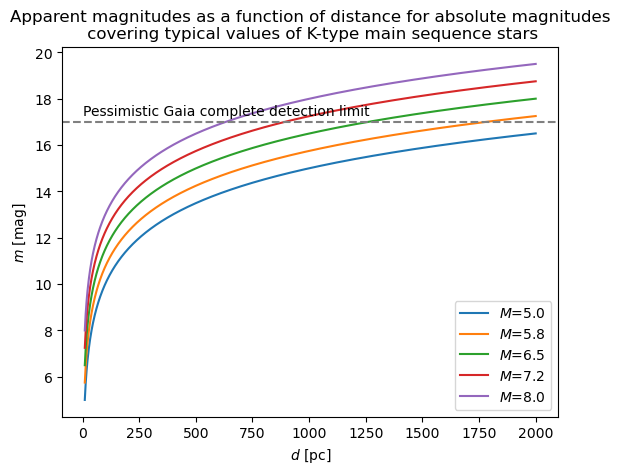

In [4]:
def M_d_to_m(M, d):
    '''Absolute magnitude M in mag, distance in pc, to apparent magnitude m in mag'''
    m = M + 5.*np.log10(d) - 5.
    return m

Ms = np.linspace(5, 8, 5) # absolute magnitude in mag
dist = np.linspace(10, 2000, 1000) # pc
for M in Ms:
    m = M_d_to_m(M, dist)
    plt.plot(dist, m, label=r"$M$={:.2}".format(M))

plt.axhline(17.0, color="gray", ls="--")
plt.text(0, 17.3, "Pessimistic Gaia complete detection limit")

plt.ylabel(r"$m$ [mag]")
plt.xlabel(r"$d$ [pc]")
plt.title("Apparent magnitudes as a function of distance for absolute magnitudes\n covering typical values of K-type main sequence stars")
plt.legend()
plt.show()
# See also https://gea.esac.esa.int/archive/documentation/GDR3/Catalogue_consolidation/chap_cu9val/sec_cu9val_introduction/ssec_cu9val_intro_completeness.html
# and links therein
# Fig.14.38 suggests that most of the persumably missed stars originiate from a mismodelled disc and high latitudes are fine (-> perhaps we can go higher than 17 mag)
# Though, I would not trust this hope. Perhaps it would be best to split the dataset into two or three (e.g. like this):
    # M=5-6 and d<2000pc
    # M=6-8 and d<1000pc

#### Selecting a subsample

In [5]:
# Distance
deg2rad = np.pi/180.
dist_pc = 1000./tab["parallax"] # in pc
# Absolute magnitude
apparent_magnitude = np.array(tab["phot_g_mean_mag"]) # 3.15 - 19.00
absolute_magnitude = apparent_magnitude - 5.*np.log10(dist_pc) + 5

# Cylinder with radius r_cyl
r_cyl = 200. # pc
mask = dist_pc * np.cos(tab["b"]*deg2rad) < r_cyl # 200 pc cylinder 
print("Requirement: Inside the cylinder of {} pc radius. Removes {:.2e} of {:.2e} sources".format(r_cyl, np.nansum(~mask), mask.size))
print("We are left with {:.2e} sources".format(np.nansum(mask)))

# Absolute magnitude limits
am_min = 5.0
am_max = 8.0 # make this smaller for better volume completeness (default 8.0)
mask2 = (absolute_magnitude>=am_min) & (absolute_magnitude<=am_max)
print("Requirement: Absolute magnitude between {} and {}. Removes an additional {:.2e} sources".format(am_min, am_max, np.nansum( (~mask2&mask) )))
print("We are left with {:.2e} sources".format(np.nansum(mask&mask2)))
tab_filtered = tab[mask&mask2] # parallax > cos(lat)*5

Requirement: Inside the cylinder of 200.0 pc radius. Removes 0.00e+00 of 6.33e+05 sources
We are left with 6.33e+05 sources
Requirement: Absolute magnitude between 5.0 and 8.0. Removes an additional 9.59e+04 sources
We are left with 5.37e+05 sources


In [7]:
# Load into separate numpy arrays
np_arr = np.array(tab_filtered)

l_np = np_arr["l"]
b_np = np_arr["b"]
ra_np = np_arr["ra"]
ra_error_np = np_arr["ra_error"]
dec_np = np_arr["dec"]
dec_error_np = np.array(tab_filtered["dec_error"])
parallax_np = np.array(tab_filtered["parallax"])
parallax_error_np = np.array(tab_filtered["parallax_error"])
pmra_np = np.array(tab_filtered["pmra"])
pmra_error_np = np.array(tab_filtered["pmra_error"])
pmdec_np = np.array(tab_filtered["pmdec"])
pmdec_error_np = np.array(tab_filtered["pmdec_error"])
phot_g_mean_mag_np = np.array(tab_filtered["phot_g_mean_mag"])
teff_gspphot_np = np.array(tab_filtered["teff_gspphot"])
bp_rp_np = np.array(tab_filtered["bp_rp"])
radial_velocity_np = np.array(tab_filtered["radial_velocity"])
radial_velocity_error_np = np.array(tab_filtered["radial_velocity_error"])

del np_arr

#### Vertical Distribution

In [8]:
###  Functions for computing the vertical velocity
def r_from_plx(plx):
    '''From parallax in mas to distance in pc'''
    return np.abs(1./np.tan(1e-3*plx))

def pm_eq_to_pm_gal(mu_alpha_cos_delta, mu_delta, alpha, delta):
    ''' In- and Output in degrees per arbitrary unit of time'''
    # from https://arxiv.org/pdf/1306.2945
    deg2rad = np.pi/180.
    deltaG = 27.12825 * deg2rad
    alphaG = 192.85948 * deg2rad
    _delta = delta * deg2rad
    _alpha = alpha * deg2rad
    C1 = np.sin(deltaG)*np.cos(_delta) - np.cos(deltaG)*np.sin(_delta)*np.cos(_alpha-alphaG)
    C2 = np.cos(deltaG)*np.sin(_alpha-alphaG)
    cos_b = np.sqrt(C1**2 + C2**2)
    mu_l_cos_b = (C1*mu_alpha_cos_delta + C2*mu_delta)/cos_b
    mu_b = (-C2*mu_alpha_cos_delta + C1*mu_delta)/cos_b
    return mu_l_cos_b, mu_b

def ra_dec_to_l_b(ra, dec):
    '''From ra and dec in degrees to l and b in degrees'''
    # See http://www.iausofa.org/2023_1011_C/sofa/icrs2g.c
    deg2rad = np.pi/180.
    deltaG = 27.12825 * deg2rad
    alphaG = 192.85948 * deg2rad
    l_ANGE = 32.93192 * deg2rad
    _ra = ra * deg2rad
    _dec = dec * deg2rad
    
    b = np.arcsin(np.cos(_dec)*np.cos(deltaG)*np.cos(_ra-alphaG)+np.sin(_dec)*np.sin(deltaG))
    x = np.sin(_ra-alphaG)*np.cos(_dec)
    y = np.sin(_dec)*np.cos(deltaG)-np.cos(_dec)*np.sin(deltaG)*np.cos(_ra-alphaG)
    l = np.arctan2(y, x) + l_ANGE
    l = np.mod(l, 2.*np.pi)
    
    return l/deg2rad, b/deg2rad

def compute_vz(plx, ra, dec, vlos, pm_ra, pm_dec,):
    """From 
    parallax in mas,
    ra and dec in degrees,
    vlos in km/s,
    pm_ra and pm_dec in mas/yr,
    to vz in km/s"""
    deg2rad = np.pi / 180.
    yr_to_sec = 3.154e7
    pc_to_km = 3.086e13
    mas_to_deg = 1./60./60./1000.
    _pm_ra = pm_ra * mas_to_deg # deg/yr
    _pm_dec = pm_dec * mas_to_deg # deg/yr
    pm_l, pm_b = pm_eq_to_pm_gal(_pm_ra, _pm_dec, ra, dec)  # deg/yr
    pm_l *=  deg2rad / yr_to_sec # rad/s
    pm_b *= deg2rad / yr_to_sec # rad/s
    l, b = ra_dec_to_l_b(ra, dec) # deg
    l *= deg2rad # rad
    b *= deg2rad # rad
    r = r_from_plx(plx) * pc_to_km  # km
    v_z = vlos * np.sin(b) + r * np.cos(b) * pm_b  # km/s
    return v_z

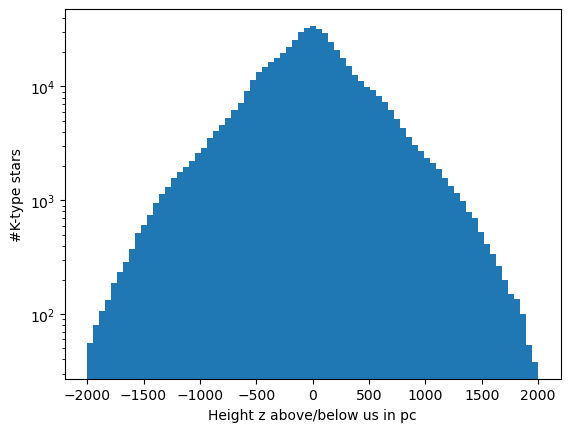

In [9]:
# Histogram in z
r_np = r_from_plx(parallax_np)
z_np = r_np * np.sin(b_np*deg2rad)

plt.hist(z_np, bins=75, range=(-2000, 2000))
plt.yscale("log")
plt.xlabel("Height z above/below us in pc")
plt.ylabel("#K-type stars")
plt.show()

#### Vertical Velocity Dispersion

Mean vertical velocity =  -7.975501361373122 km/s


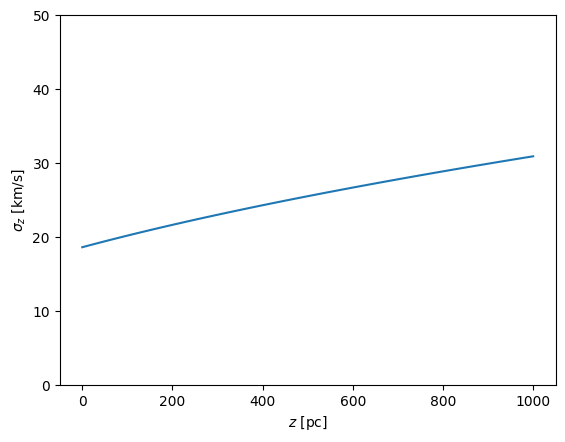

In [12]:
# Compute vertical velocity dispersion
vz = compute_vz(parallax_np, ra_np, dec_np, radial_velocity_np, pmra_np, pmdec_np)
hasv = np.isfinite(vz)
vmean = np.mean(vz[hasv])
print("Mean vertical velocity = ", vmean, "km/s")
v2 = (vz[hasv]-vmean)**2

# Lets fit a simple curve
POLYNOME_ORDER = 1
v2_fit = np.poly1d(np.polyfit(np.abs(z_np)[hasv], v2, POLYNOME_ORDER))
zs = np.linspace(0, 1000, 100)
sigmas = np.sqrt(v2_fit(zs))
plt.plot(zs, sigmas)
plt.ylim(0, 50)
plt.xlabel(r"$z$ [pc]")
plt.ylabel(r"$\sigma_z$ [km/s]")
plt.show()